In [2]:
%pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

# Cell 1: Import Libraries and Check Dependencies
from ultralytics import YOLO
import os
import torch
import torchvision
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
from pathlib import Path
from time import time
import yaml
import json
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported successfully!
PyTorch version: 2.10.0+cpu
CUDA available: False


In [11]:
# Cell 2: Dataset Path Configuration
DATASET_PATH = "/content/drive/MyDrive/Before Augumentation/Multi-Weather Pothole Detection (MWPD)/MWPD"
YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")
MODEL_SAVE_PATH = "/content/drive/MyDrive/yolo v5n/s"
TFLITE_SAVE_PATH = "/content/drive/MyDrive/yolo v5n/t"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(TFLITE_SAVE_PATH, exist_ok=True)

print(f"Using dataset path: {DATASET_PATH}")
print(f"Models will be saved to: {MODEL_SAVE_PATH}")
print("Expected dataset structure:")
print("   train/")
print("   ├── images/")
print("   └── labels/")
print("   val/")
print("   ├── images/")
print("   └── labels/")
print("   test/ (optional)")
print("       ├── images/")
print("       └── labels/")

Using dataset path: /content/drive/MyDrive/Before Augumentation/Multi-Weather Pothole Detection (MWPD)/MWPD
Models will be saved to: /content/drive/MyDrive/yolo v5n/s
Expected dataset structure:
   train/
   ├── images/
   └── labels/
   val/
   ├── images/
   └── labels/
   test/ (optional)
       ├── images/
       └── labels/


In [12]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# Assuming DATASET_PATH is available from previous cells (Cell 2)

all_bbox_data = []

print(f"Collecting bounding box data from: {DATASET_PATH}")

# Use standard split names directly to avoid dependency on dataset_info
splits_to_check = ['train', 'valid', 'test']

# Collect data from all splits
for split in splits_to_check:
    labels_dir = Path(DATASET_PATH) / split / 'labels'
    if labels_dir.exists():
        print(f"Processing labels in {split} split...")
        for label_file in tqdm(list(labels_dir.glob('*.txt')), desc=f"Loading {split} labels"):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        # Assuming class_id, x_center, y_center, width, height
                        # We'll use x_center, y_center, width, height for PCA
                        all_bbox_data.append([float(p) for p in parts[1:]]) # Exclude class_id

if not all_bbox_data:
    print("No bounding box data found. Please ensure your label files contain bounding box annotations.")
else:
    bbox_df = pd.DataFrame(all_bbox_data, columns=['x_center', 'y_center', 'width', 'height'])
    print(f"Collected {len(bbox_df)} bounding box entries.")
    display(bbox_df.head())


Processing labels in train split...


Loading train labels: 100%|██████████| 2730/2730 [00:51<00:00, 52.93it/s] 


Processing labels in valid split...


Loading valid labels: 100%|██████████| 260/260 [00:03<00:00, 86.15it/s] 


Processing labels in test split...


Loading test labels: 100%|██████████| 97/97 [00:26<00:00,  3.70it/s]

Collected 7331 bounding box entries.


,x_center,y_center,width,height
0,0.571827,0.647757,0.335021,0.401103
1,0.172615,0.316647,0.302892,0.223229
2,0.718187,0.295594,0.091976,0.085697
3,0.539850,0.280088,0.185491,0.191706
4,0.443263,0.676963,0.200711,0.094323


PCA explained variance ratio:
PC1: 0.46
PC2: 0.25
Total explained variance: 0.71


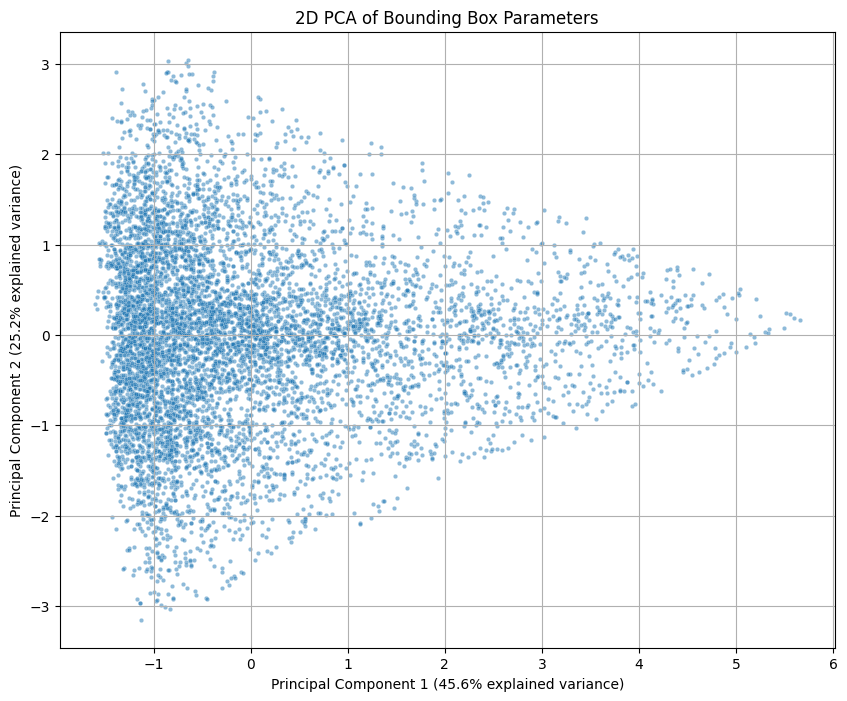


3D PCA explained variance ratio:
PC1: 0.46
PC2: 0.25
PC3: 0.25
Total explained variance: 0.96


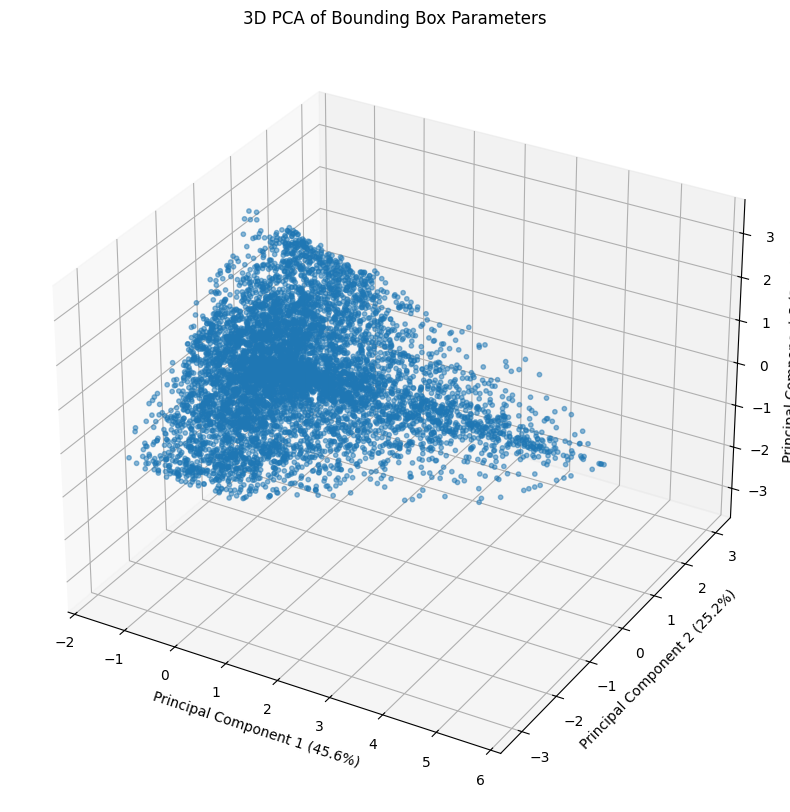

In [13]:
if 'bbox_df' in locals() and not bbox_df.empty:
    # Initialize PCA with 2 components for 2D visualization
    pca = PCA(n_components=2)

    # Fit PCA to the bounding box data and transform it
    # Standardize the data before PCA, as PCA is sensitive to scale
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaled_bbox_data = scaler.fit_transform(bbox_df)

    principal_components = pca.fit_transform(scaled_bbox_data)

    # Create a DataFrame for the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])

    print("PCA explained variance ratio:")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.2f}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.2f}")
    print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='principal_component_1', y='principal_component_2', data=pca_df, alpha=0.5, s=10)
    plt.title('2D PCA of Bounding Box Parameters')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% explained variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% explained variance)')
    plt.grid(True)
    plt.show()

    # Optional: 3D PCA
    if len(bbox_df.columns) >= 3:
        pca_3d = PCA(n_components=3)
        principal_components_3d = pca_3d.fit_transform(scaled_bbox_data)
        pca_df_3d = pd.DataFrame(data=principal_components_3d, columns=['pc1', 'pc2', 'pc3'])

        print("\n3D PCA explained variance ratio:")
        print(f"PC1: {pca_3d.explained_variance_ratio_[0]:.2f}")
        print(f"PC2: {pca_3d.explained_variance_ratio_[1]:.2f}")
        print(f"PC3: {pca_3d.explained_variance_ratio_[2]:.2f}")
        print(f"Total explained variance: {pca_3d.explained_variance_ratio_.sum():.2f}")

        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(pca_df_3d['pc1'], pca_df_3d['pc2'], pca_df_3d['pc3'], alpha=0.5, s=10)
        ax.set_xlabel(f'Principal Component 1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'Principal Component 2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
        ax.set_zlabel(f'Principal Component 3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
        plt.title('3D PCA of Bounding Box Parameters')
        plt.show()
else:
    print("Cannot perform PCA: Bounding box DataFrame is empty or not created.")


Calculating Wasserstein Distance between Train, Valid, and Test splits...
Found 6466 train bboxes, 573 valid bboxes, and 292 test bboxes.
Wasserstein Distance for x_center - Train vs Valid: 0.0083, Train vs Test: 0.0147
Wasserstein Distance for y_center - Train vs Valid: 0.0090, Train vs Test: 0.0370
Wasserstein Distance for width - Train vs Valid: 0.0121, Train vs Test: 0.0333
Wasserstein Distance for height - Train vs Valid: 0.0104, Train vs Test: 0.0473


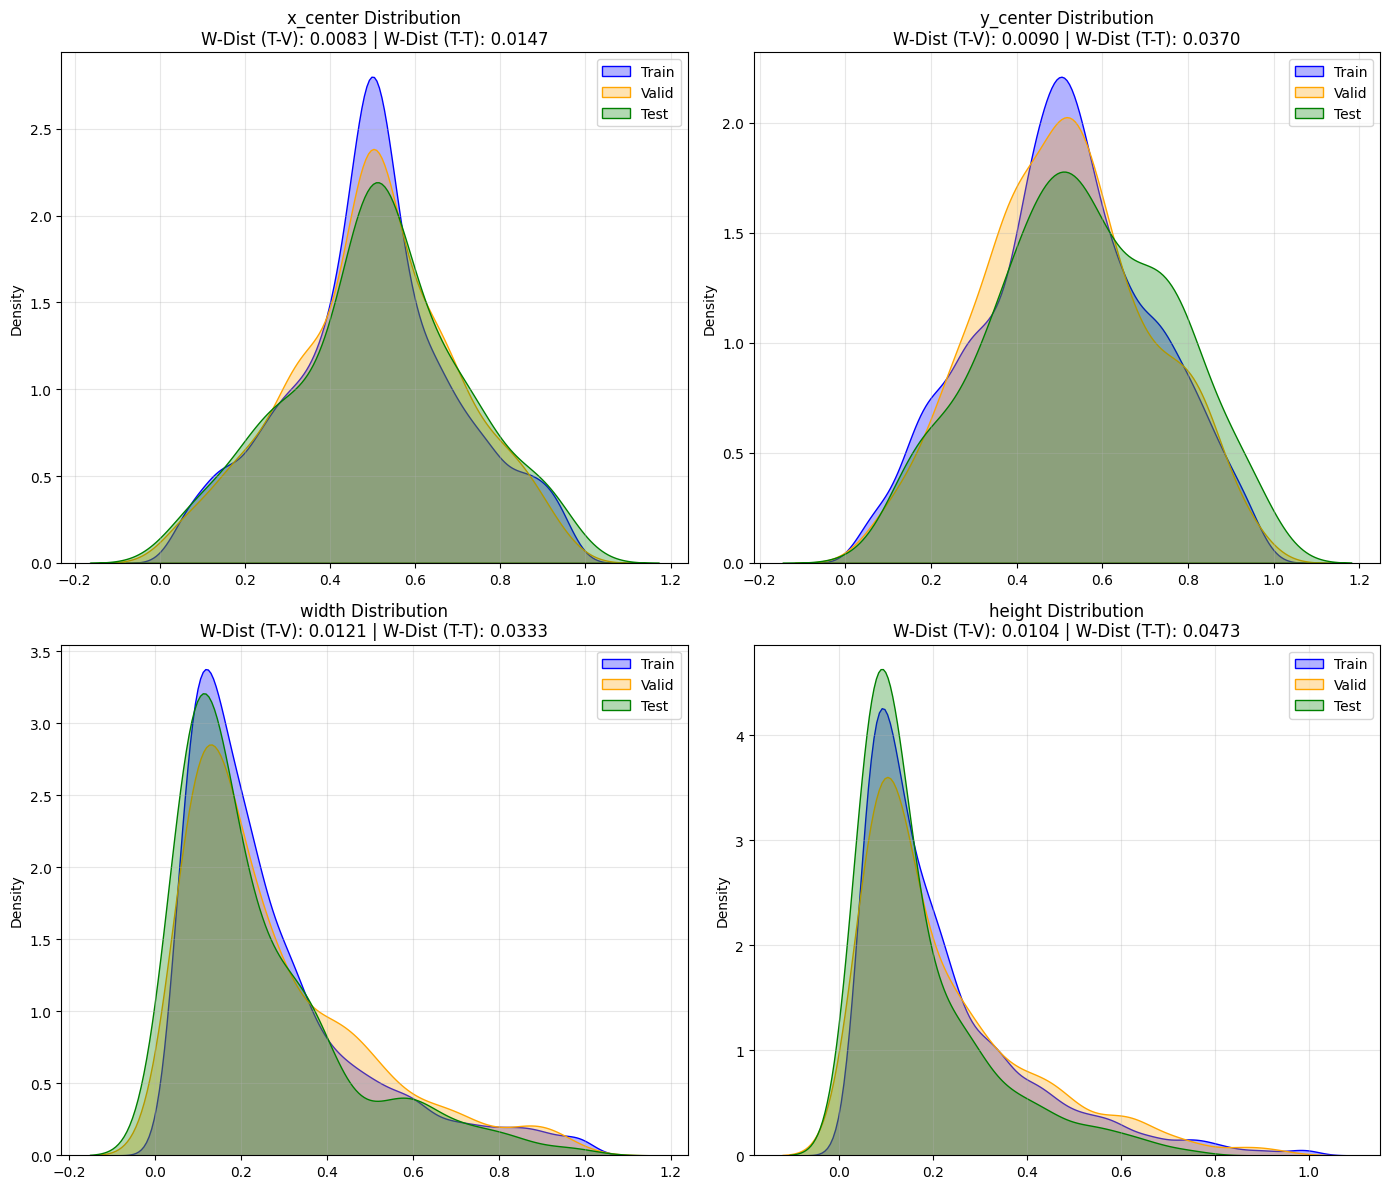

In [17]:
import numpy as np
from scipy.stats import wasserstein_distance
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming DATASET_PATH is available from Cell 2
print("Calculating Wasserstein Distance between Train, Valid, and Test splits...")

def get_bboxes_from_split(split_name):
    bboxes = []
    labels_dir = Path(DATASET_PATH) / split_name / 'labels'
    if labels_dir.exists():
        for label_file in labels_dir.glob('*.txt'):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        # Exclude class_id, keep x_center, y_center, width, height
                        bboxes.append([float(p) for p in parts[1:]])
    return np.array(bboxes) if bboxes else np.empty((0, 4))

train_bboxes = get_bboxes_from_split('train')
valid_bboxes = get_bboxes_from_split('valid')
test_bboxes = get_bboxes_from_split('test')

if len(train_bboxes) > 0 and len(valid_bboxes) > 0:
    params = ['x_center', 'y_center', 'width', 'height']
    w_distances_valid = {}
    w_distances_test = {}

    print(f"Found {len(train_bboxes)} train bboxes, {len(valid_bboxes)} valid bboxes, and {len(test_bboxes)} test bboxes.")

    for i, param in enumerate(params):
        # Compute 1D Wasserstein distance for each parameter
        dist_v = wasserstein_distance(train_bboxes[:, i], valid_bboxes[:, i])
        w_distances_valid[param] = dist_v

        if len(test_bboxes) > 0:
            dist_t = wasserstein_distance(train_bboxes[:, i], test_bboxes[:, i])
            w_distances_test[param] = dist_t
            print(f"Wasserstein Distance for {param} - Train vs Valid: {dist_v:.4f}, Train vs Test: {dist_t:.4f}")
        else:
            print(f"Wasserstein Distance for {param} - Train vs Valid: {dist_v:.4f}")

    # Plotting the distributions to visualize the distance
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, param in enumerate(params):
        sns.kdeplot(train_bboxes[:, i], ax=axes[i], label='Train', fill=True, alpha=0.3, color='blue')
        sns.kdeplot(valid_bboxes[:, i], ax=axes[i], label='Valid', fill=True, alpha=0.3, color='orange')

        title = f'{param} Distribution\nW-Dist (T-V): {w_distances_valid[param]:.4f}'

        if len(test_bboxes) > 0:
            sns.kdeplot(test_bboxes[:, i], ax=axes[i], label='Test', fill=True, alpha=0.3, color='green')
            title += f' | W-Dist (T-T): {w_distances_test[param]:.4f}'

        axes[i].set_title(title)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compare Train and Valid splits. Please check your DATASET_PATH.")

In [14]:
%pip install umap-learn

Performing UMAP dimensionality reduction... This might take a minute.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


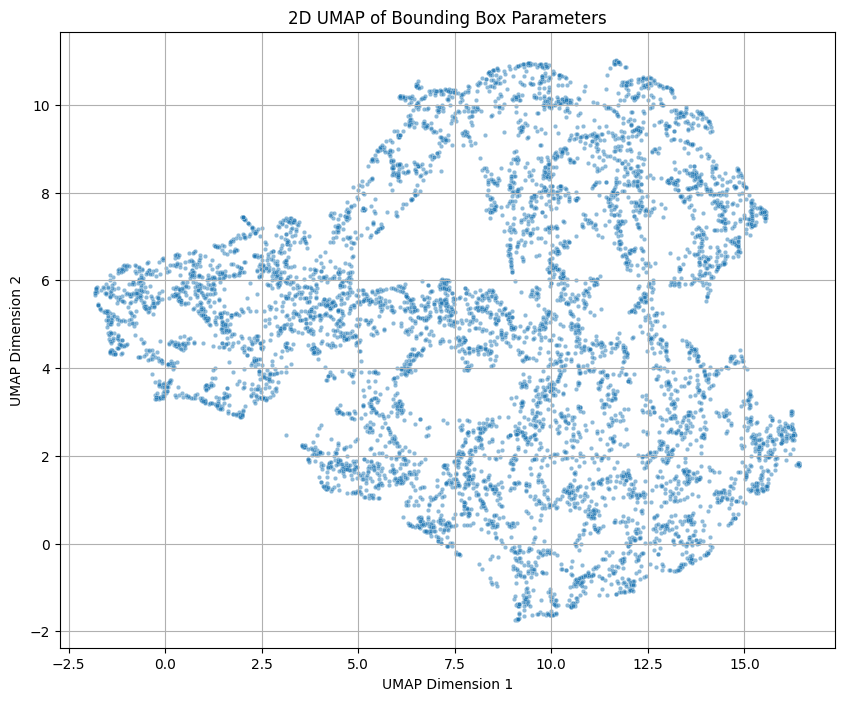


Performing 3D UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


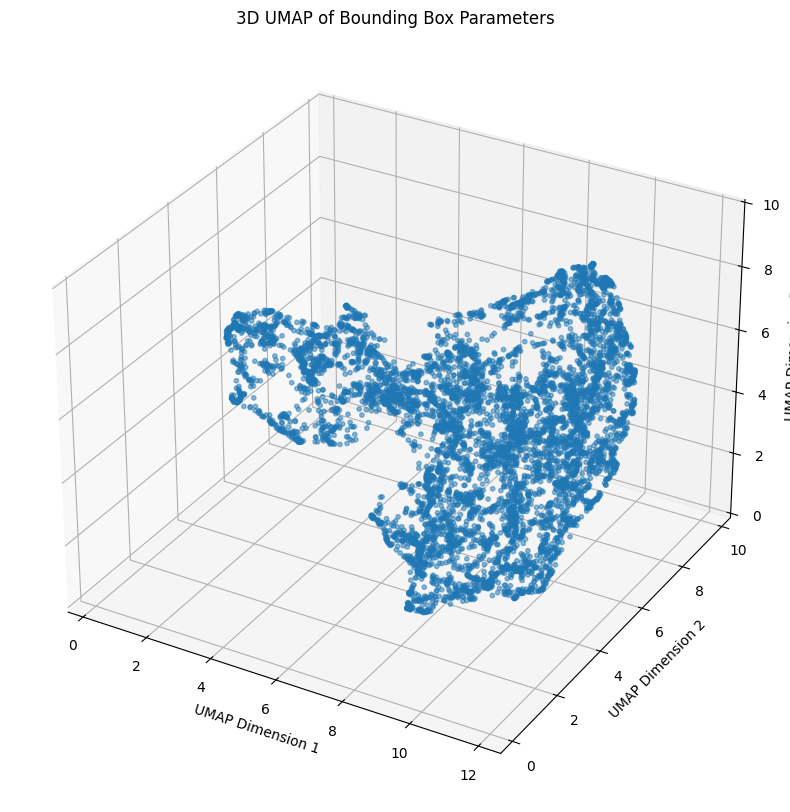

In [15]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'scaled_bbox_data' in locals():
    print("Performing UMAP dimensionality reduction... This might take a minute.")

    # Initialize UMAP for 2D
    reducer_2d = umap.UMAP(n_components=2, random_state=42)

    # Fit and transform the data
    embedding_2d = reducer_2d.fit_transform(scaled_bbox_data)

    # Create a DataFrame for the UMAP results
    umap_df_2d = pd.DataFrame(data=embedding_2d, columns=['UMAP_1', 'UMAP_2'])

    # Plot the 2D results
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='UMAP_1', y='UMAP_2', data=umap_df_2d, alpha=0.5, s=10)
    plt.title('2D UMAP of Bounding Box Parameters')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.grid(True)
    plt.show()

    # Optional: 3D UMAP
    if scaled_bbox_data.shape[1] >= 3:
        print("\nPerforming 3D UMAP...")
        reducer_3d = umap.UMAP(n_components=3, random_state=42)
        embedding_3d = reducer_3d.fit_transform(scaled_bbox_data)
        umap_df_3d = pd.DataFrame(data=embedding_3d, columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])

        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(umap_df_3d['UMAP_1'], umap_df_3d['UMAP_2'], umap_df_3d['UMAP_3'], alpha=0.5, s=10)
        ax.set_xlabel('UMAP Dimension 1')
        ax.set_ylabel('UMAP Dimension 2')
        ax.set_zlabel('UMAP Dimension 3')
        plt.title('3D UMAP of Bounding Box Parameters')
        plt.show()
else:
    print("Error: 'scaled_bbox_data' not found. Please ensure the PCA cell was run beforehand.")

Performing t-SNE dimensionality reduction... This might take a minute or two.


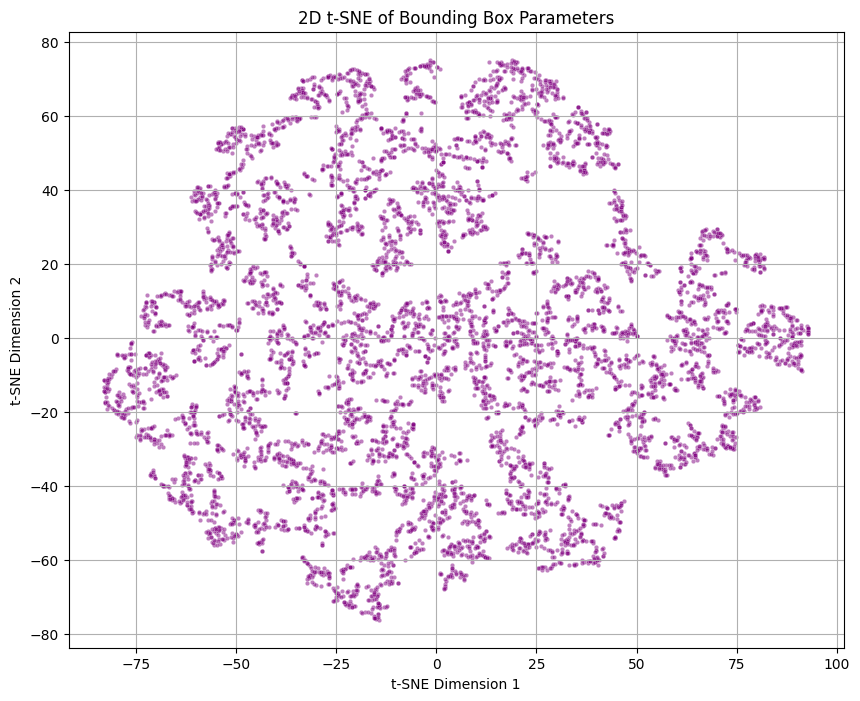

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'scaled_bbox_data' in locals():
    print("Performing t-SNE dimensionality reduction... This might take a minute or two.")

    # Initialize t-SNE for 2D
    tsne = TSNE(n_components=2, random_state=42)

    # Fit and transform the data
    tsne_results = tsne.fit_transform(scaled_bbox_data)

    # Create a DataFrame for the t-SNE results
    tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE_1', 't-SNE_2'])

    # Plot the 2D results
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='t-SNE_1', y='t-SNE_2', data=tsne_df, alpha=0.5, s=10, color='purple')
    plt.title('2D t-SNE of Bounding Box Parameters')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True)
    plt.show()
else:
    print("Error: 'scaled_bbox_data' not found. Please ensure the PCA cell was run beforehand.")